# Import

In [2]:
#the usual 
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, DataStructs, rdFingerprintGenerator, PandasTools, Descriptors
PandasTools.RenderImagesInAllDataFrames(images=False) # when true, it displays the structures in the DF output

#others
#from sklearn.metrics import jaccard_score
from matplotlib.colors import LogNorm
from tqdm import tqdm
from itertools import combinations

In [3]:
import rdkit
print(rdkit.__version__)

2025.09.3


# Hafner data set

## load dataset

In [4]:

# url = "https://media.githubusercontent.com/media/FennerLabs/pepper/refs/heads/main/data/soil/cpd_data_soil_all_data.tsv"
# dataset = pd.read_csv(url, sep='\t')

# downloaded it locally:
dataset = pd.read_csv('data/cpd_data_soil_all_data.tsv', sep='\t')


df = dataset[['compound_name', 'SMILES']].copy()
df['Structure'] = df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
df

,compound_name,SMILES,Structure
0,"1,3-Dichloropropene",ClC=CCCl,<rdkit.Chem.rdchem.Mol object at 0x0000023893D...
1,3-Chloroallyl alcohol,OCC=CCl,<rdkit.Chem.rdchem.Mol object at 0x0000023893D...
2,3-Chloroacrylic acid,O=C([O-])C=CCl,<rdkit.Chem.rdchem.Mol object at 0x0000023893D...
3,1-naphthylacetamide,NC(=O)Cc1cccc2ccccc12,<rdkit.Chem.rdchem.Mol object at 0x0000023893D...
4,1-naphthoic acid (M2),O=C(O)c1cccc2ccccc12,<rdkit.Chem.rdchem.Mol object at 0x0000023893D...
...,...,...,...
862,X11963422,CC1OC(=O)C(Cc2ccccc2)C1O,<rdkit.Chem.rdchem.Mol object at 0x0000023893D...
863,X696476,COc1ccnc(C(=O)O)c1O,<rdkit.Chem.rdchem.Mol object at 0x0000023893D...
864,XDE-777,COc1ccnc(C(=O)NC2COC(=O)C(Cc3ccccc3)C(OC(=O)C(...,<rdkit.Chem.rdchem.Mol object at 0x0000023893D...
865,X642188,COc1ccnc(C(=O)NC2COC(=O)C(Cc3ccccc3)C(OC(=O)C(...,<rdkit.Chem.rdchem.Mol object at 0x0000023893D...


## define generators 

In [16]:
# generators 
sizes = [256, 1024, 2048, 4096, 8192, 16384, 32768]

fp_generators = {
    "TopologicalTorsion": {
        "sparse": rdFingerprintGenerator.GetTopologicalTorsionGenerator(),
        "folded": {size: rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=size) for size in sizes}
    },
    "ECFP4": {
        "sparse": rdFingerprintGenerator.GetMorganGenerator(radius=2),
        "folded": {size: rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=size) for size in sizes}
    },
    "ECFP6": {
        "sparse": rdFingerprintGenerator.GetMorganGenerator(radius=3),
        "folded": {size: rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=size) for size in sizes}
    },
    "AtomPair": {
        "sparse": rdFingerprintGenerator.GetAtomPairGenerator(),
        "folded": {size: rdFingerprintGenerator.GetAtomPairGenerator(fpSize=size) for size in sizes}
    },
    "RDKit": {
        "sparse": rdFingerprintGenerator.GetRDKitFPGenerator(),
        "folded": {size: rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=size) for size in sizes}
    }
}


## Self collison count

In [ ]:
# run only once; results are stored in json collison_count

all_results = []

# loop over each generator
for fp_name, gens in fp_generators.items():
    records = []

    # calculate the number of on bits for sparse and folded for each molecule
    for mol in tqdm(df["Structure"], desc=f"Processing {fp_name}"):
        rec = {"fingerprint": fp_name}

        # sparse bits
        rec["sparse_bits"] = len(gens["sparse"].GetSparseFingerprint(mol).GetOnBits())

        # folded bits
        for size, gen in gens["folded"].items():
            rec[f"folded_bits_{size}"] = gen.GetFingerprint(mol).GetNumOnBits()

        records.append(rec)

    fp_df = pd.DataFrame(records)

    # percentage of molecules where folding changed bit count
    percent_col = { size: (fp_df["sparse_bits"] != fp_df[f"folded_bits_{size}"]).sum() * 100 / len(fp_df) for size in sizes}
    
    s = pd.Series(percent_col, name=fp_name)
    all_results.append(s)

summary_df = pd.DataFrame(all_results)
summary_df = summary_df.T

#store df
summary_df.to_json('data/pest_collision_count.json')

#display
summary_df

In [17]:
with open('data/pest_collision_count.json') as f: 
    collision_count = pd.DataFrame(json.load(f))

collision_count.index = collision_count.index.astype(int)
collision_count

,TopologicalTorsion,ECFP4,ECFP6,AtomPair,RDKit
256,74.163783,88.465975,92.733564,96.539792,98.615917
1024,37.831603,55.247982,68.627451,85.467128,97.462514
2048,20.876586,46.020761,55.478662,78.431373,97.116494
4096,13.379469,13.610150,22.145329,67.358708,95.386390
8192,8.996540,6.805075,11.880046,56.632065,94.117647
16384,4.036909,2.883506,5.767013,54.555940,90.657439
32768,2.191465,1.384083,2.652826,33.217993,83.275663


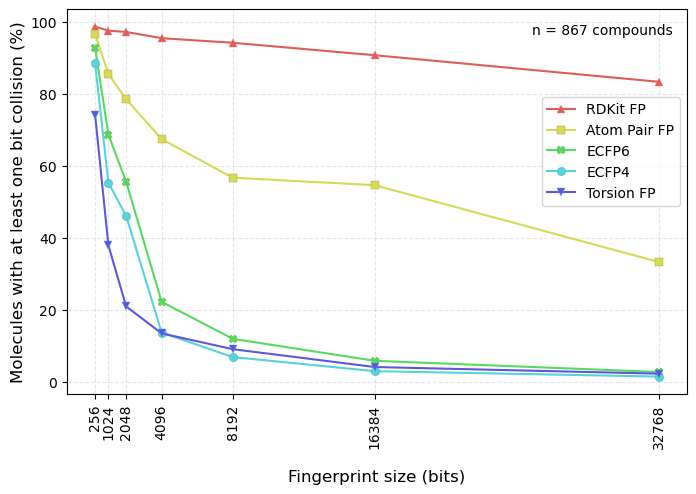

In [20]:
# %% plot the results 

labels = ["RDKit FP", "Atom Pair FP", "ECFP6" , "ECFP4" , "Torsion FP"  ]
order = ["RDKit", "AtomPair", "ECFP6" , "ECFP4" , "TopologicalTorsion"] 
markers = [ '^', 's', 'X' , 'o' , 'v', ]
n=len(df)
i=0
plt.figure(figsize=(8,5))
for fp in order:
    plt.plot(collision_count[fp], marker=markers[i], label=labels[i], color=sns.color_palette("hls")[i], markeredgecolor=sns.color_palette("husl")[i],
                    markeredgewidth=.3,)
    i=i+1

plt.xlabel("Fingerprint size (bits)", size=12, labelpad=15)
plt.ylabel('Molecules with at least one bit collision (%)',size=12)
plt.xticks(sizes, rotation=90, size=10)
plt.yticks(size=10)
plt.legend( bbox_to_anchor=(1, 0.79) )
plt.grid(True, linestyle="--", alpha=0.3)
plt.text( x=33600, y=96.5, s=f'n = {n} compounds', horizontalalignment = 'right')
plt.savefig('new_figures/pest_selfcol_count.svg', bbox_inches='tight')
plt.show()

## Similarity searching effects

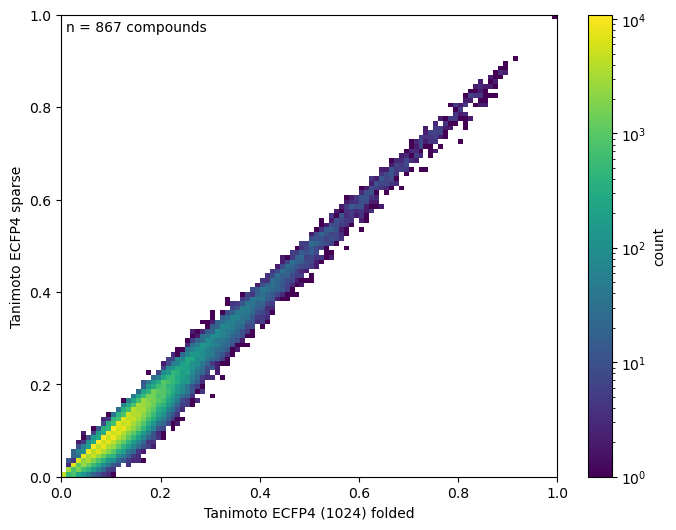

In [19]:
## ecfp4 

mols = df.Structure
n = len(mols)

# fingerprints
ecfp4 = [rdFingerprintGenerator.GetMorganGenerator(radius = 2, fpSize=1024).GetFingerprint(m) for m in mols]
sparse_ecfp4 = [rdFingerprintGenerator.GetMorganGenerator(radius=2).GetSparseFingerprint(m) for m in mols]

# initialize histogram
counts = np.zeros((100, 100))

# loop over molecules, compare against all later ones
for i in range(n):
    sims_fold = DataStructs.BulkTanimotoSimilarity(ecfp4[i], ecfp4[i+1:])
    sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_ecfp4[i], sparse_ecfp4[i+1:])
    
    # update histogram 
    hist, _, _ = np.histogram2d(
        sims_fold, sims_sparse,
        bins=100, range=[[0,1],[0,1]]
    )
    counts += hist

# mask zero-count bins
counts_masked = np.ma.masked_where(counts == 0, counts)

# plot
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    np.linspace(0,1,101),
    np.linspace(0,1,101),
    counts_masked.T,
    cmap="viridis",
    norm=LogNorm(vmin=1, vmax=counts.max())) # log scale is needed

plt.colorbar(label="count")
plt.xlabel("Tanimoto ECFP4 (1024) folded")
plt.ylabel("Tanimoto ECFP4 sparse")
plt.text( x= 0.01, y=0.965,  s=f'n = {n} compounds')
# plt.title(f"Similarity scores for unfolded vs folded ECFP4 \nfor {n} compounds")
#plt.savefig('new_figures/pesticide_ecfp_sim_plot.svg', bbox_inches='tight')
plt.show()


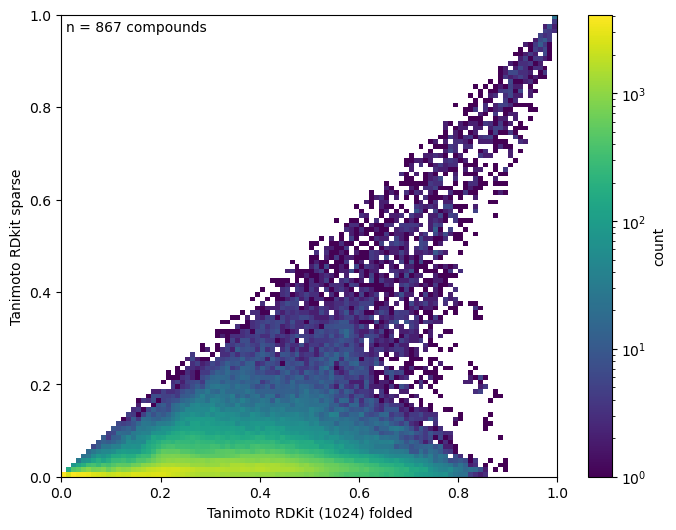

In [3]:
# now for RDkit 

mols = df.Structure
n = len(mols)

# fingerprints
rdkitfp = [rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=1024).GetFingerprint(m) for m in mols]
sparse_rdkitfp= [rdFingerprintGenerator.GetRDKitFPGenerator().GetSparseFingerprint(m) for m in mols]

# initialize histogram
counts = np.zeros((100, 100))

# loop over molecules, compare against all later ones
for i in range(n):
    sims_fold = DataStructs.BulkTanimotoSimilarity(rdkitfp[i], rdkitfp[i+1:])
    sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_rdkitfp[i], sparse_rdkitfp[i+1:])
    
    # update histogram 
    hist, _, _ = np.histogram2d(
        sims_fold, sims_sparse,
        bins=100, range=[[0,1],[0,1]]
    )
    counts += hist

# mask zero-count bins
counts_masked = np.ma.masked_where(counts == 0, counts)

# plot
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    np.linspace(0,1,101),
    np.linspace(0,1,101),
    counts_masked.T,
    cmap="viridis",
    norm=LogNorm(vmin=1, vmax=counts.max())) # log scale is needed

plt.colorbar(label="count")
plt.xlabel("Tanimoto RDKit (1024) folded")
plt.ylabel("Tanimoto RDkit sparse")
plt.text( x= 0.01, y=0.965,  s=f'n = {n} compounds')
# plt.title(f"Similarity scores for unfolded vs folded ECFP4 \nfor {n} compounds")
#plt.savefig('new_figures/pesticide_rdkit_sim_plot.svg', bbox_inches='tight')
plt.show()


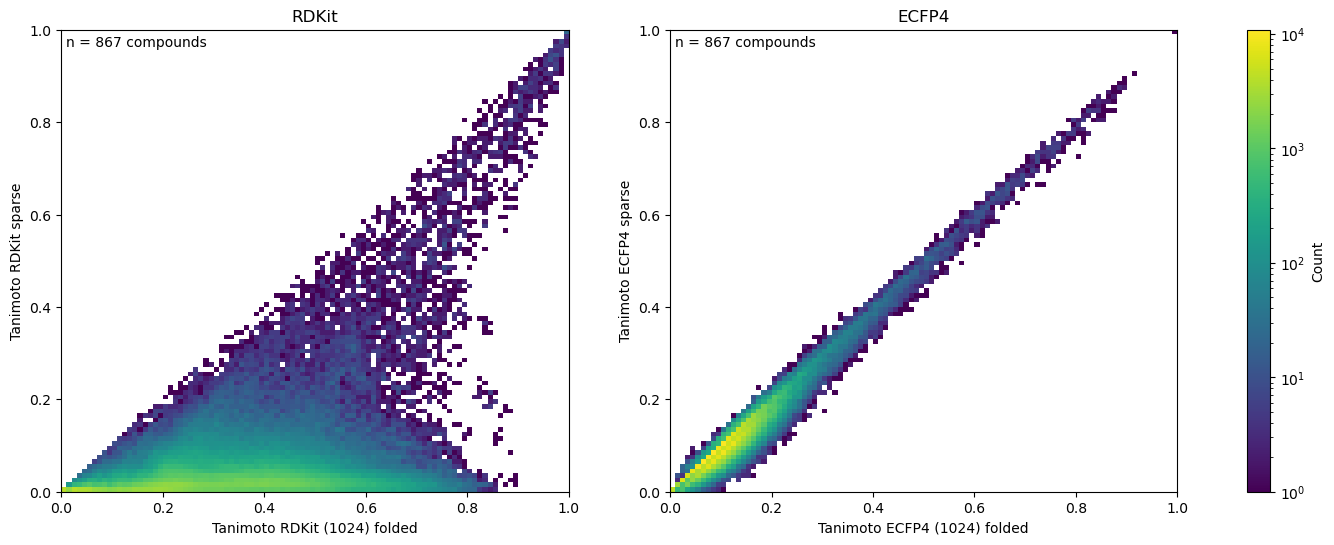

In [12]:
# # i want them in one plot with same scale 

# mols = df.Structure
# n = len(mols)

# # ECFP4 
# ecfp4 = [rdFingerprintGenerator.GetMorganGenerator(radius = 2, fpSize=1024).GetFingerprint(m) for m in mols]
# sparse_ecfp4 = [rdFingerprintGenerator.GetMorganGenerator(radius=2).GetSparseFingerprint(m) for m in mols]
# counts_ecfp4 = np.zeros((100, 100))

# # loop over molecules, compare against all later ones
# for i in range(n):
#     sims_fold = DataStructs.BulkTanimotoSimilarity(ecfp4[i], ecfp4[i+1:])
#     sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_ecfp4[i], sparse_ecfp4[i+1:])
    
#     # update histogram 
#     hist, _, _ = np.histogram2d(
#         sims_fold, sims_sparse,
#         bins=100, range=[[0,1],[0,1]]
#     )
#     counts_ecfp4 += hist

# counts_masked_ecfp4 = np.ma.masked_where(counts_ecfp4 == 0, counts_ecfp4)

# # RDKit 
# rdkitfp = [rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=1024).GetFingerprint(m) for m in mols]
# sparse_rdkitfp= [rdFingerprintGenerator.GetRDKitFPGenerator().GetSparseFingerprint(m) for m in mols]
# counts_rdkit = np.zeros((100, 100))

# for i in range(n):
#     sims_fold = DataStructs.BulkTanimotoSimilarity(rdkitfp[i], rdkitfp[i+1:])
#     sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_rdkitfp[i], sparse_rdkitfp[i+1:])
    
#     # update histogram 
#     hist, _, _ = np.histogram2d(
#         sims_fold, sims_sparse,
#         bins=100, range=[[0,1],[0,1]]
#     )
#     counts_rdkit += hist

# counts_masked_rdkit = np.ma.masked_where(counts_rdkit == 0, counts_rdkit)


# # colour scale 
# vmax = max(counts_ecfp4.max(),counts_rdkit.max())
# norm = LogNorm(vmin=1,vmax=vmax)


# figure

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.linspace(0, 1, 101)
y = np.linspace(0, 1, 101)

# RDKit
im1 = axes[0].pcolormesh(
    x,
    y,
    counts_masked_rdkit.T,
    cmap="viridis",
    norm=norm
)

axes[0].set_xlabel("Tanimoto RDKit (1024) folded")
axes[0].set_ylabel("Tanimoto RDKit sparse")
axes[0].set_title("RDKit")
axes[0].text(0.01, 0.965, f"n = {n} compounds")

# ECFP4
im2 = axes[1].pcolormesh(
    x,
    y,
    counts_masked_ecfp4.T,
    cmap="viridis",
    norm=norm)

axes[1].set_xlabel("Tanimoto ECFP4 (1024) folded")
axes[1].set_ylabel("Tanimoto ECFP4 sparse")
axes[1].set_title("ECFP4")
axes[1].text(0.01, 0.965, f"n = {n} compounds")


fig.colorbar(
    im1,
    ax=axes,
    label="Count",
)

plt.savefig('new_figures/comb_scale_sim_plot.svg', bbox_inches='tight')
plt.show()


In [5]:
df["rdkit_fp"] = df['Structure'].apply(lambda x: rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=1024).GetFingerprint(x))

jaccard_similarities = {}

for row1, row2 in combinations(df.index, 2):
    sim = DataStructs.cDataStructs.TanimotoSimilarity(df["rdkit_fp"][row1], df["rdkit_fp"][row2])
    jaccard_similarities[(row1, row2)] = sim

# to Series and filter
high_jaccard = pd.Series(jaccard_similarities)
high_jaccard = high_jaccard[high_jaccard > 0.75]
high_jaccard = high_jaccard.sort_values(ascending=False)

high_jaccard

266  267    1.000000
264  425    1.000000
     426    1.000000
302  727    1.000000
100  102    1.000000
              ...   
398  755    0.750251
191  397    0.750250
35   715    0.750250
184  386    0.750249
609  764    0.750249
Length: 2174, dtype: float64

In [6]:
df["rdkit_sparse_fp"] = df['Structure'].apply(lambda x: rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=1024).GetSparseFingerprint(x))

sparse_jaccard_similarities = {}

for row1, row2 in combinations(df.index, 2):
    sim = DataStructs.cDataStructs.TanimotoSimilarity(df["rdkit_sparse_fp"][row1], df["rdkit_sparse_fp"][row2])
    sparse_jaccard_similarities[(row1, row2)] = sim

# to Series and filter
low_jaccard = pd.Series(sparse_jaccard_similarities)
low_jaccard = low_jaccard[low_jaccard < 0.1]
low_jaccard = low_jaccard.sort_values(ascending=False)

low_jaccard

337  609    0.099937
     610    0.099935
665  799    0.099924
43   489    0.099922
445  857    0.099907
              ...   
0    47     0.000000
     19     0.000000
     17     0.000000
     11     0.000000
     10     0.000000
Length: 354050, dtype: float64

In [28]:
round(low_jaccard.loc[pair],2)


np.float64(0.04)

In [ ]:

pairs = high_jaccard.index.intersection(low_jaccard.index)
pairs

for pair in pairs:
    mols = [df.iloc[pair[0]]['Structure'] , df.iloc[pair[1]]['Structure']] 
    img = Draw.MolsToGridImage( mols, molsPerRow=2, legends = [f'Unfolded: {round(low_jaccard.loc[pair],2)} \nFolded: {round(high_jaccard.loc[pair],2)}', ''], subImgSize=(200,200))
    display(img)


# Large general dataset

## Load dataset, curate and move to pickle 

In [ ]:
# load data from the zero pm github
url = "https://raw.githubusercontent.com/ZeroPM-H2020/global-chemical-inventory-database/refs/heads/main/csv_files/substances.csv"
df = pd.read_csv(url)

# inchi to structure 
df[  "Structure"  ] = df[  "inchi"  ].apply(lambda x: Chem.inchi.MolFromInchi(x))

# drop everything that doesnt work 
to_drop = df.loc[df[  "Structure"  ].isnull() == True].index
df = df.drop(to_drop)
df.shape

# safe the new df
zeropm_substances = "zeropm_substances.csv"
df.to_csv(zeropm_substances, index=False)

In [ ]:
import operator as op

# import dataframe of the compounds without errors
df = pd.read_csv("zeropm_substances.csv")

#remove salts  
df[  "Salt"  ] = df[  inchi  ].apply(lambda x: op.contains(x, "." ))
df = df.loc[df[  "Salt"  ] == False]

# re-run structure as this doesnt save in csv
df[  "Structure"  ] = df[  "inchi"  ].apply(lambda x: Chem.inchi.MolFromInchi(x, sanitize=True, removeHs=True))

# remove the single atoms and diatoms
df[  "NumAtoms"  ] = df[  "Structure"  ].apply(lambda x: x.GetNumAtoms())
df = df.loc[df[  "NumAtoms"  ] > 2]

df = df.set_index(  "inchi_id"  )
df.shape

In [ ]:
# safe df in pickle so the molfrominchi does not have to be rerun
df.to_pickle("./substances.pkl")  

## Load data

In [21]:
df_gen = pd.read_pickle("data/substances.pkl") 
df_gen

,inchi,inchikey,Structure,Salt,NumAtoms
inchi_id,,,,,
1,InChI=1S/C6H4ClNO2/c7-5-1-3-6(4-2-5)8(9)10/h1-4H,CZGCEKJOLUNIFY-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x0000015F605...,False,10
2,InChI=1S/C6H6N2O2/c7-5-1-3-6(4-2-5)8(9)10/h1-4...,TYMLOMAKGOJONV-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x0000015F605...,False,10
3,"InChI=1S/C6H5NO3/c8-6-3-1-5(2-4-6)7(9)10/h1-4,8H",BTJIUGUIPKRLHP-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x0000015F605...,False,10
4,InChI=1S/C6H5ClO2S/c7-5-1-3-6(4-2-5)10(8)9/h1-...,AOQYAMDZQAEDLO-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x0000015F605...,False,10
7,InChI=1S/C9H10O2/c1-7(10)8-3-5-9(11-2)6-4-8/h3...,NTPLXRHDUXRPNE-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x0000015F605...,False,11
...,...,...,...,...,...
359105,"InChI=1S/O6Si2/c1-7(2)6-8(3,4)5/q-4",NYRJGAMJBNFXOM-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x0000015FB4C...,False,8
359107,"InChI=1S/O7Si2/c1-8(2,3)7-9(4,5)6/q-6",KUDCBYUNCUYIDU-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x0000015FB4C...,False,9
359108,InChI=1S/O7Si3/c1-8(2)6-10(5)7-9(3)4/q-2,MXSSWTMUAUJAKG-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x0000015FB4C...,False,10


## Self collision count

In [ ]:
# run only once; results are stored in json collison_count

all_results = []

# loop over each generator
for fp_name, gens in fp_generators.items():
    records = []

    # calculate the number of on bits for sparse and folded for each molecule
    for mol in tqdm(df["Structure"], desc=f"Processing {fp_name}"):
        rec = {"fingerprint": fp_name}

        # sparse bits
        rec["sparse_bits"] = len(gens["sparse"].GetSparseFingerprint(mol).GetOnBits())

        # folded bits
        for size, gen in gens["folded"].items():
            rec[f"folded_bits_{size}"] = gen.GetFingerprint(mol).GetNumOnBits()

        records.append(rec)

    fp_df = pd.DataFrame(records)

    # percentage of molecules where folding changed bit count
    percent_col = { size: (fp_df["sparse_bits"] != fp_df[f"folded_bits_{size}"]).sum() * 100 / len(fp_df) for size in sizes}
    
    s = pd.Series(percent_col, name=fp_name)
    all_results.append(s)

summary_df = pd.DataFrame(all_results)
summary_df = summary_df.T

#store df
summary_df.to_json('data/general_collision_count.json')

#display
summary_df

In [22]:
with open('data/general_collision_count.json') as f: 
    gen_collision_count = pd.DataFrame(json.load(f))

gen_collision_count.index = gen_collision_count.index.astype(int)
gen_collision_count


,TopologicalTorsion,ECFP4,ECFP6,AtomPair,RDKit
256,65.434830,80.328636,88.014726,97.164558,98.634486
1024,28.968536,46.978545,58.691180,77.151719,95.897658
2048,16.975528,37.989589,46.502877,64.541116,92.885097
4096,11.099295,10.023049,18.532082,51.727485,88.550722
8192,7.775810,6.102852,11.187854,35.873449,84.515283
16384,5.245878,2.847044,5.947390,31.435433,79.724190
32768,4.251616,1.080500,2.437893,19.133048,70.465303


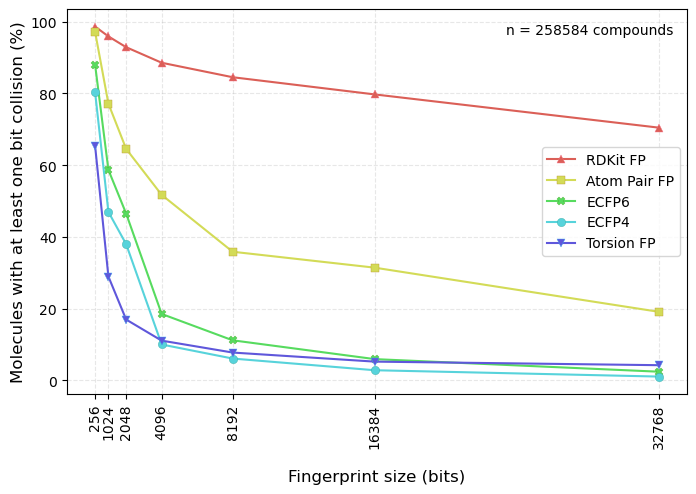

In [23]:
labels = ["RDKit FP", "Atom Pair FP", "ECFP6" , "ECFP4" , "Torsion FP"  ]
order = ["RDKit", "AtomPair", "ECFP6" , "ECFP4" , "TopologicalTorsion"] 
markers = [ '^', 's', 'X' , 'o' , 'v', ]
n=len(df_gen)

i=0
plt.figure(figsize=(8,5))
for fp in order:
    plt.plot(gen_collision_count[fp], marker=markers[i], label=labels[i], color=sns.color_palette("hls")[i], markeredgecolor=sns.color_palette("husl")[i],
                    markeredgewidth=.3,)
    i=i+1

plt.xlabel("Fingerprint size (bits)", size=12, labelpad=15)
plt.ylabel('Molecules with at least one bit collision (%)',size=12)
plt.xticks(sizes, rotation=90, size=10)
plt.yticks(size=10)
plt.legend( )
plt.grid(True, linestyle="--", alpha=0.3)
plt.text( x=33600, y=96.5, s=f'n = {n} compounds', horizontalalignment = 'right')
plt.savefig('new_figures/general_selfcol_count.svg', bbox_inches='tight')
plt.show()

### per size class

In [32]:
def size(x):
    if x<20: 
        return 'x-small'
    if x<75:
        return 'small'
    if x<200:
        return 'medium'
    else:
        return 'large'

df_gen['Size'] = df_gen['NumAtoms'].apply(lambda x: size(x))
grouped_wt = df_gen.groupby('Size')
grouped_wt.size()

Size
large         208
medium       2386
small       97432
x-small    158558
dtype: int64

In [ ]:

# run ECFP4 for different sized molecules and save as json 

sizes = [256, 1024, 2048, 4096, 8192, 16384, 32768]
fp_gen_sparse = rdFingerprintGenerator.GetMorganGenerator(radius=2)
fp_gens_folded = {size: rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=size) for size in sizes}


summary_rows = []

for size_class, group in grouped_wt:

    records = []
    
    # loop over molecules with tqdm progress bar
    for mol in tqdm(group['Structure'], desc=f"Processing molecules for class {size_class}"):
        rec = {}
        
        # sparse bits count
        rec["sparse_bits"] = len(fp_gen_sparse.GetSparseFingerprint(mol).GetOnBits())
        
        # folded bits counts
        for size, gen in fp_gens_folded.items():
            rec[f"folded_bits_{size}"] = gen.GetFingerprint(mol).GetNumOnBits()
        records.append(rec)
    
    bit_col_df = pd.DataFrame(records)

    row = {"Size class": size_class}
    for size in sizes:
        row[size] = ((bit_col_df["sparse_bits"] != bit_col_df[f"folded_bits_{size}"]).mean()* 100)

    summary_rows.append(row)

size_df = pd.DataFrame(summary_rows)

size_df = size_df.set_index('Size class')
size_df = size_df.T

size_df.to_json('data/general_count_weight_ECFP4.json')

size_df


In [37]:
with open('data/general_count_weight_ECFP4.json') as f: 
    size_df = pd.DataFrame(json.load(f))

size_df.index = size_df.index.astype(int)
size_df

,large,medium,small,x-small
256,99.519231,97.359598,94.293456,71.465962
1024,97.115385,84.534786,64.346416,35.675273
2048,95.192308,79.882649,53.850891,27.537557
4096,56.730769,41.072925,18.011536,4.585704
8192,55.288462,28.792959,11.146235,2.597788
16384,27.884615,16.512992,5.125626,1.208391
32768,27.403846,7.544007,2.016791,0.373365


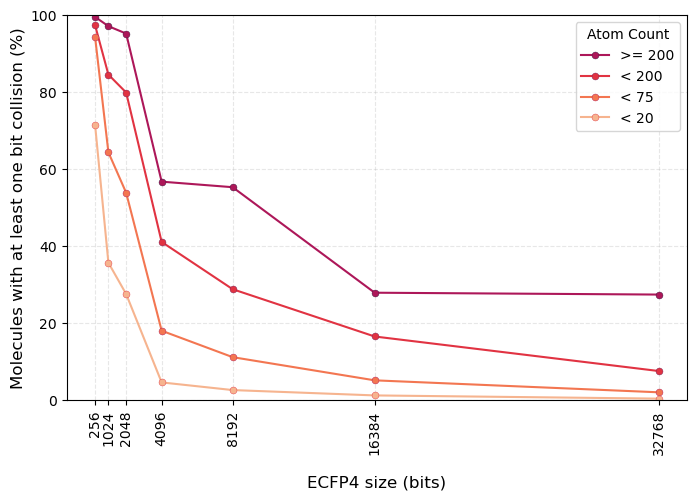

In [39]:

labels = ['>= 200', '< 200' , '< 75' , '< 20' ]

i=0
plt.figure(figsize=(8,5))
for col in size_df.columns:
    plt.plot(size_df[col], label=labels[i], marker = '.', markersize = 10,  color=sns.color_palette("rocket")[i+2], markeredgecolor=sns.color_palette("rocket")[i],
                    markeredgewidth=.3,)
    i=i+1

plt.xlabel("ECFP4 size (bits)", size=12, labelpad=15)
plt.ylabel('Molecules with at least one bit collision (%)',size=12)

plt.xticks(sizes, rotation=90, size=10)
plt.yticks(size=10)
plt.ylim(0,100)
plt.legend( title='Atom Count' )
plt.grid(True, linestyle="--", alpha=0.3)
plt.savefig('new_figures/general_selfcol_pw.svg', bbox_inches='tight')

plt.show()

## Similarity searching effect 

In [ ]:
# define
df_sample = df_gen.sample(n=5000, random_state=42)
mols = df_sample.Structure
n = len(mols)

sizes = [256, 1024, 2048, 4096, 8192]

for fp_name, gens in fp_generators.items():

    # sparse fingerprints
    sparse_fp = [gens["sparse"].GetSparseFingerprint(m) for m in mols]

    # folded fingerprints
    fingerprints = {size: [gens["folded"][size].GetFingerprint(m) for m in mols] for size in sizes}
    
    # subplot grid
    fig, axes = plt.subplots(1, len(sizes), figsize=(6*len(sizes), 4), sharex=True, sharey=True)
    
    for ax, size in zip(axes, sizes):
        fp = fingerprints[size]
        counts = np.zeros((100, 100))
    
        # make the 2d historgram
        for i in tqdm(range(n), desc=f"Processing fpSize={size}", unit="mol"):
            sims_fold = DataStructs.BulkTanimotoSimilarity(fp[i], fp[i+1:])
            sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_fp[i], sparse_fp[i+1:])
            
            hist, _, _ = np.histogram2d(
                sims_fold, sims_sparse,
                bins=100, range=[[0,1],[0,1]]
            )
            counts += hist
    
        # mask zero-count bin
        counts_masked = np.ma.masked_where(counts == 0, counts)
    
        # subplot
        mesh = ax.pcolormesh(
            np.linspace(0,1,101),
            np.linspace(0,1,101),
            counts_masked.T,
            cmap="viridis",
            norm=LogNorm(vmin=1, vmax=counts.max())
        )
        ax.set_xlabel(f"Tanimoto folded")
        ax.set_ylabel(f"Tanimoto sparse")
        ax.set_title(f"{fp_name}; {size} bits")
    
    #one shared colorbar
    fig.colorbar(mesh, ax=axes, label="count", pad=0.02)
    #  fig.suptitle(f"Similarity scores for unfolded vs folded {fp_name} for {n} compounds", fontsize=20, y=1.1, x=0.2)
    plt.savefig(f"new_figures/gen_{fp_name}_similarity.svg", bbox_inches="tight")
    plt.show()

# Machine learning Figures

In [41]:
with open('data/model_results.json', 'r') as f:
    model_output = json.load(f)

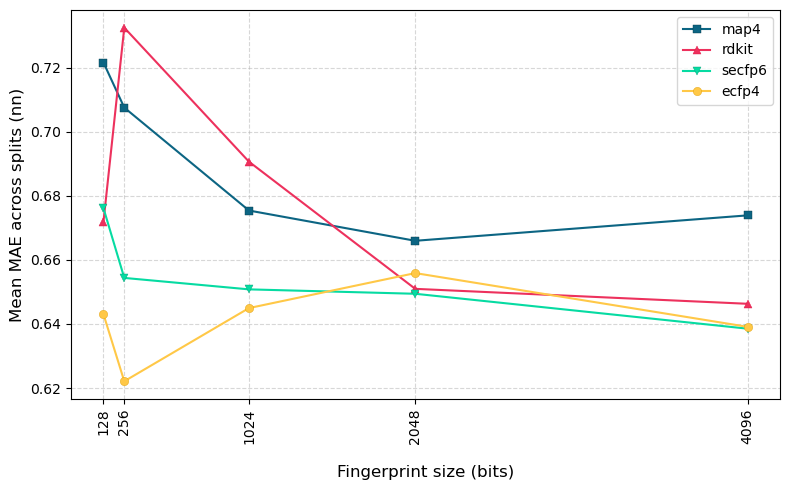

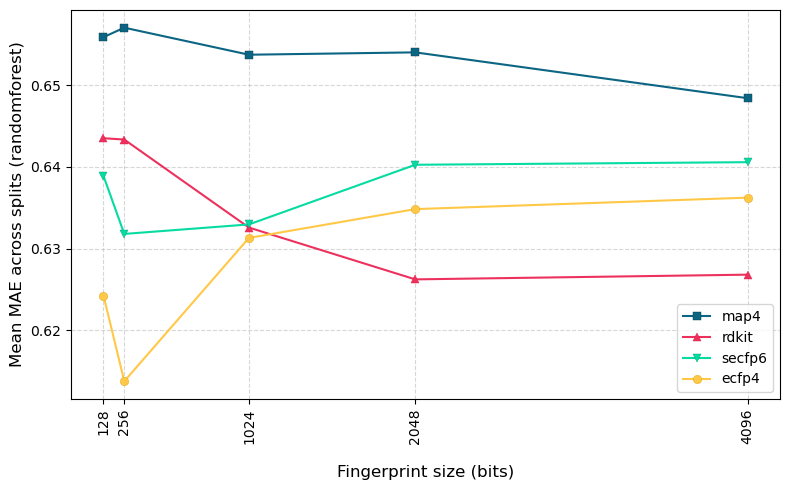

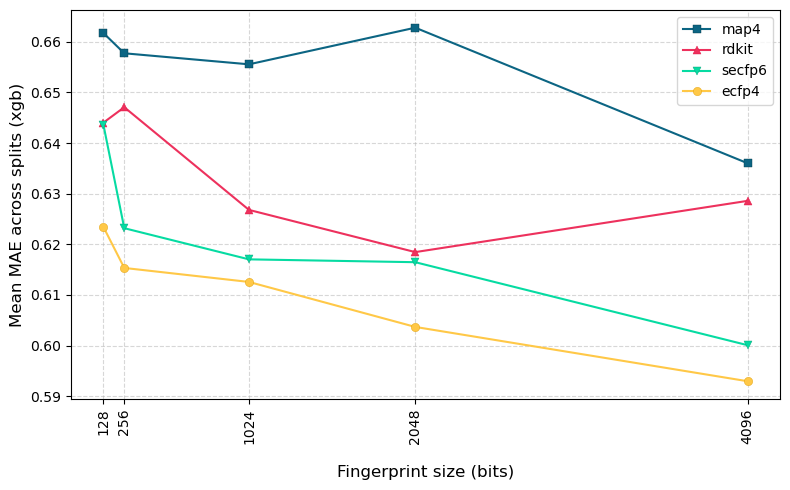

In [36]:
order = ['map4', 'rdkit', 'secfp6', 'ecfp4']

rows = []
for key, split_dict in model_output.items():
    model_type, encoding, bitlen = key.rsplit("_", 2)
    bitlen = int(bitlen)
    for split_idx, metrics in split_dict.items():
        mae = metrics.get("mae", None)
        if mae is not None:
            rows.append({
                "model_type": model_type,
                "encoding": encoding,
                "bits": bitlen,
                "split": int(split_idx),
                "mae": mae
            })

df = pd.DataFrame(rows)

mean_mae_df = df.groupby(["model_type", "encoding", "bits"])["mae"].mean().reset_index()
mean_mae_df['std'] = df.groupby(["model_type", "encoding", "bits"])["mae"].std().reset_index()['mae']


for model_type, model_df in mean_mae_df.groupby("model_type"):
    pivot_df_mean = model_df.pivot(index="encoding", columns="bits", values="mae").sort_index(axis=1)
    pivot_df_mean = pivot_df_mean.reindex(order)

    pivot_df_std = model_df.pivot(index="encoding", columns="bits", values="std").sort_index(axis=1)
    pivot_df_std = pivot_df_std.reindex(order)

    
    fig, ax = plt.subplots(figsize=(8,5))
    
    # styles = {
    #     "map4": {"marker": "s", "color": 'red'},
    #     "rdkit": {"marker": "^", "color": 'orange'},
    #     "secfp6": {"marker": "v", "color": 'green'},
    #     "ecfp4": {"marker": "o", "color": 'blue'}
    # }


    # styles = {
    #     "map4": {"marker": "s", "color": '#EF436B', 'markeredgecolor': '#BC1038', 'markeredgewidth': .3},
    #     "rdkit": {"marker": "^", "color": '#FFC847', 'markeredgecolor': '#E09D00', 'markeredgewidth': .3},
    #     "secfp6": {"marker": "v", "color": '#06D6A0', 'markeredgecolor': '#058A66', 'markeredgewidth': .3},
    #     "ecfp4": {"marker": "o", "color": '#1082A8', 'markeredgecolor': '#0C6583', 'markeredgewidth': .3}
    # }

    styles = {
        "map4": {"marker": "s", "color": '#0C6583', 'markeredgecolor': '#073A4B', 'markeredgewidth': .3},
        "rdkit": {"marker": "^", "color": '#ED315D', 'markeredgecolor': '#E11444', 'markeredgewidth': .3},
        "secfp6": {"marker": "v", "color": '#06DBA2', 'markeredgecolor': '#049F76', 'markeredgewidth': .3},
        "ecfp4": {"marker": "o", "color": '#FFC847', 'markeredgecolor': '#E09D00', 'markeredgewidth': .3}
    }
    
    for encoding, row in pivot_df_mean.iterrows():
        x = pivot_df_mean.columns.tolist()
        y = row.values.astype(float)
        ax.plot(x, y, label=encoding, **styles.get(encoding))


    # x = pivot_df_mean.columns.tolist()
    # for encoding in order:
    #     plt.errorbar(
    #         x= x,
    #         y = pivot_df_mean.loc[encoding],
    #         yerr=pivot_df_std.loc[encoding],
    #         label=encoding,
    #         **styles.get(encoding),
    #     )

    # ax.set_ylim(0.585, 0.75)
    ax.set_xlabel("Fingerprint size (bits)", size=12, labelpad=15)
    ax.set_ylabel(f"Mean MAE across splits ({model_type})",size=12)
    ax.set_xticks(pivot_df_mean.columns)
    ax.tick_params(axis='x', labelrotation=90)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

    fig.tight_layout()
    fig.savefig(f"new_figures/mean_mae_{model_type}_pesticides.svg")


In [37]:
with open('data/model_results_lipo.json', 'r') as f:
    model_output = json.load(f)

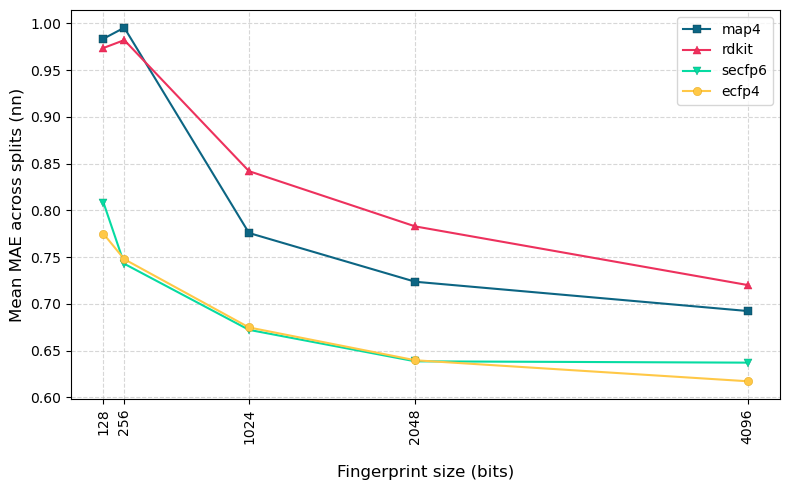

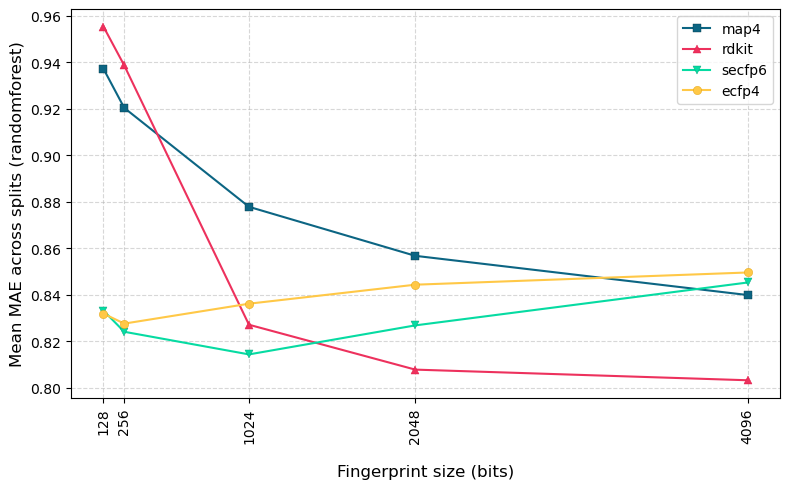

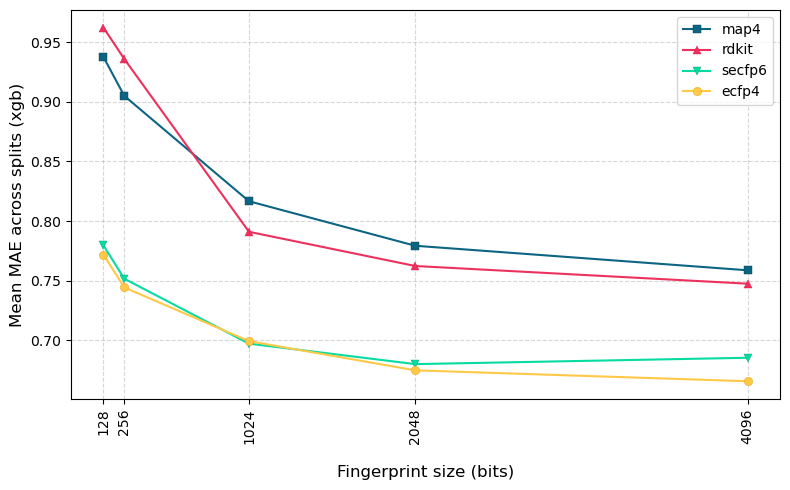

In [38]:
order = ['map4', 'rdkit', 'secfp6', 'ecfp4']

rows = []
for key, split_dict in model_output.items():
    model_type, encoding, bitlen = key.rsplit("_", 2)
    bitlen = int(bitlen)
    for split_idx, metrics in split_dict.items():
        mae = metrics.get("mae", None)
        if mae is not None:
            rows.append({
                "model_type": model_type,
                "encoding": encoding,
                "bits": bitlen,
                "split": int(split_idx),
                "mae": mae
            })

df = pd.DataFrame(rows)

mean_mae_df = df.groupby(["model_type", "encoding", "bits"])["mae"].mean().reset_index()
mean_mae_df['std'] = df.groupby(["model_type", "encoding", "bits"])["mae"].std().reset_index()['mae']


for model_type, model_df in mean_mae_df.groupby("model_type"):
    pivot_df_mean = model_df.pivot(index="encoding", columns="bits", values="mae").sort_index(axis=1)
    pivot_df_mean = pivot_df_mean.reindex(order)

    pivot_df_std = model_df.pivot(index="encoding", columns="bits", values="std").sort_index(axis=1)
    pivot_df_std = pivot_df_std.reindex(order)

    
    fig, ax = plt.subplots(figsize=(8,5))


    styles = {
        "map4": {"marker": "s", "color": '#0C6583', 'markeredgecolor': '#073A4B', 'markeredgewidth': .3},
        "rdkit": {"marker": "^", "color": '#ED315D', 'markeredgecolor': '#E11444', 'markeredgewidth': .3},
        "secfp6": {"marker": "v", "color": '#06DBA2', 'markeredgecolor': '#049F76', 'markeredgewidth': .3},
        "ecfp4": {"marker": "o", "color": '#FFC847', 'markeredgecolor': '#E09D00', 'markeredgewidth': .3}
    }

    
    
    for encoding, row in pivot_df_mean.iterrows():
        x = pivot_df_mean.columns.tolist()
        y = row.values.astype(float)
        ax.plot(x, y, label=encoding, **styles.get(encoding))


    # x = pivot_df_mean.columns.tolist()
    # for encoding in order:
    #     plt.errorbar(
    #         x= x,
    #         y = pivot_df_mean.loc[encoding],
    #         yerr=pivot_df_std.loc[encoding],
    #         label=encoding,
    #         **styles.get(encoding),
    #     )

    # ax.set_ylim(0.585, 0.75)
    ax.set_xlabel("Fingerprint size (bits)", size=12, labelpad=15)
    ax.set_ylabel(f"Mean MAE across splits ({model_type})",size=12)
    ax.set_xticks(pivot_df_mean.columns)
    ax.tick_params(axis='x', labelrotation=90)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

    fig.tight_layout()
    fig.savefig(f"new_figures/mean_mae_{model_type}_lipo.svg")

